# Bermuda Sea Level Rise Practical

Welcome to the Bermuda Sea Level Practical. In this session, we are going to use existing Python code to analyse a sea level time series from the Bermuda tide gauge, and a hydrographic time series from the BATS site. The aim is to determine the rate of sea level rise in Bermuda, and what proportion of this sea level rise can be attributed to volume changes (steric effects) over changes in mass or glacial isostatic adjustment. Although the code in these analyses are already written for you, you will need to change parameters to explore the data. 

_Originally written by Pete Davis, University of Oxford. Later modifications by Helen Johnson and Noam Vogt-Vincent._

* _Version 1.0 - Completed August 2013 (Matlab)_
* _Version 1.1 - Completed September 2013 (Removed bugs in the plotting routines)_
* _Version 1.2 - Completed February 2016 (Corrected spelling and grammar mistakes)_
* _Version 1.3 - Completed August 2026 (Complete rewrite in Python using ChatGPT-5.6 Sol, manually corrected and modified and merged with accompanying PDF)_

### Environment

This practical is provided in an online Binder notebook. You can run a local version of the notebook if you wish by downloading this repository and running the following code:

```bash
conda env create -f environment.yml
conda activate bermuda
jupyter lab
```

## Import external packages and helper functions

In addition to standard packages (numpy, pandas, scipy, matplotlib...), this practical uses two key additional external packages: `UTide` is a widely-used package for tidal analysis that was ported from the original version in Matlab. `gsw` is the maintained Python interface to TEOS-10 (Thermodynamic Equation Of Seawater 2010) that allows us to precisely calculate the density of water based on temperature, pressure, and salinity. Please run the following code to import all these packages.

In [1]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy
import gsw
from utide import solve, reconstruct
from slprac_functions import *

# Check that all libraries are present and print version numbers for reproducibility.
for package in ["numpy", "pandas", "scipy", "matplotlib", "utide", "gsw"]:
    try:
        print(f"{package:10s} {version(package)}")
    except PackageNotFoundError:
        raise ImportError(package + "is required. Please ensure the correct environment is activated.")

# Set up basic plotting parameters in Matplotlib to make later plotting scripts more concise.
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Approximate geographic coordinates used by the analyses.
# UTide only requires latitude; TEOS-10 salinity conversion requires both.
TIDE_GAUGE_LAT = 32.37
BATS_LAT = 31.67
BATS_LON = -64.17

numpy      2.5.2
pandas     3.0.5
scipy      1.18.0
matplotlib 3.11.1
utide      0.3.1
gsw        3.6.23


## Load the tide-gauge and hydrographic data

The archived tide-gauge record runs from 1932 to 2012. The BATS processed file contains hydrographic profiles from 1955 to 2011. Newer files can later be substituted in the two path variables below. Please run the following code to import these datasets.

In [2]:
TIDE_GAUGE_FILE = locate_practical_file(
    "processed_data/Tide_Gauge_Data/Hourly_Height_Verified_Water_Level.mat"
)
BATS_TS_FILE = locate_practical_file(
    "processed_data/TS_Data/BATS_TS_DATA_1955_2010.mat"
)

# Print basic summary information about the imported data
tg = load_tide_gauge(TIDE_GAUGE_FILE)
print(f"Tide gauge: {tg.index.min()} to {tg.index.max()}")
print(f"Hourly samples: {len(tg):,}; valid: {tg.notna().sum():,}; missing: {tg.isna().sum():,}")
print(f"BATS file: {BATS_TS_FILE}")

Tide gauge: 1932-01-01 00:00:00 to 2012-12-31 23:00:00
Hourly samples: 613,656; valid: 525,701; missing: 87,955
BATS file: /home/nvogt/Documents/Teaching/bermuda_slprac/processed_data/TS_Data/BATS_TS_DATA_1955_2010.mat


# Section 1 — Visualising the Bermuda tide-gauge record

The aim of this section is to load the complete sea level record from the Bermuda tide gauge, and plot the data over varying periods of time. The dataset runs from 1 January 1932 to 31 December 2012. Try plotting 5 days, 20 days, 1 year, 10 years, and 80 years (the complete record) worth of data. Can you think what might be causing the variability you are seeing over the different time periods?

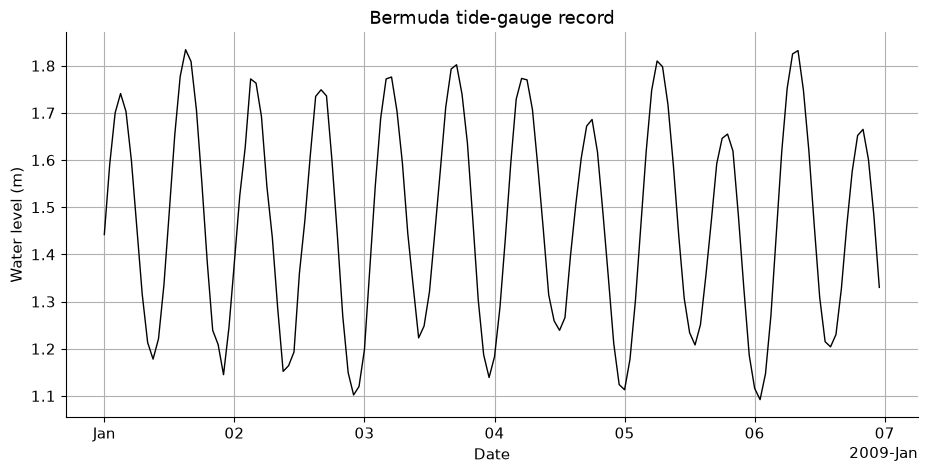

In [3]:
# Define start and end times of the plot (format YYYY-MM-DD)
PLOT_START = "2009-01-01"
PLOT_END = "2009-01-06"

# Extract a subset of the tide gauge data
view = tg.loc[PLOT_START:PLOT_END]

# Create a figure
fig, ax = plt.subplots()
ax.plot(view.index, view, lw=1, c='k')
ax.set(xlabel="Date", ylabel="Water level (m)", title="Bermuda tide-gauge record")
format_date_axis(ax)
plt.show()

# Section 2 — Detiding and harmonic tidal analysis

To look at the longer term variability in the dataset, we first need to remove the short term (high frequency) variability. This can be achieved through a variety of different methods, including simple running averages or using Fourier transforms to filter the dataset in frequency space. However, in the case of tides where we know the exact frequencies we want to remove, it is preferable to use a least squares technique known as _harmonic analysis_ to remove the tidal variability. This is because you can specify the exact frequencies you want to remove in a harmonic analysis, whilst with a Fourier transform the frequencies that can be resolved depend on the length of the dataset and the time increment, and there is therefore no guarantee that they will lie on the exact tidal frequencies.

In general, the tides are very long period waves that travel through the ocean in response to the gravitational interactions between the Earth, moon, sun, and other celestial bodies. Each one of these interactions takes the shape of a sinusoidal curve with an associated amplitude, phase, and frequency. The oceanic response to each separate interaction also takes the form of a sinusoidal curve, with each curve represented as an individual tidal constituent (e.g. M2, S2, etc.). Overall, there are hundreds of different tidal constituents, all with different frequencies. As a result, the signature of the tides in sea level is very asymmetrical. You can find a list of key tidal constituents [here](https://en.wikipedia.org/wiki/Theory_of_tides#Tidal_constituents). However, usually 7-10 constituents dominate. 

Harmonic analysis essentially fits sine waves to the data at the frequency of the tidal constituents selected to be included in the analysis, and optimises their amplitude and phase to minimise the least squared difference between the actual data and fitted wine waves. We can use this information to reconstruct a synthetic tidal curve, which can be subtracted from the actual data to produce a _detided_ dataset. 

**Start by running a harmonic analysis on 1 year's worth of data\* (defined by `HARMON_START` and `HARMON_END`). In the code below, you can choose which tidal constituents you want to fit to the sea level record, and the second and third code blocks will produce a table of fitted tidal constituents and the resulting detrended sea level record. Compare the fitted tidal constituents to NOAA's analysis for the Bermuda sea level record [here](https://tidesandcurrents.noaa.gov/harcon.html?id=2695540). Do your results agree? If not, why not?**

**Vary the number of tidal constituents that are fitted and see how this affected the variability in the residual 'detided' sea level curve (green). Where is this residual variability arising from? How many tidal constituents do you need to include in your analysis to remove the tides sufficiently? Adjust the plot length to see the effect of removing different constituents. Why might it be difficult to distinguish two components with similar frequencies, and how could you mitigate this?**

\* We will run a longer analysis in the next section.

In [4]:
# ANALYSIS PARAMETERS
HARMON_START = "2005-01-01"
HARMON_END = "2006-01-01"

# CHOOSE WHICH TIDAL CONSTITUENTS TO ANALYSE
# See [here](https://en.wikipedia.org/wiki/Theory_of_tides#Tidal_constituents)
# Try, for example:
# ["M2", "S2", "N2", "K1"]
# ["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"]
# "auto"
HARMON_CONSTITUENTS = ["M2", "S2", "N2", "K1"]

# PERFORM HARMONIC ANALYSIS
analysis = tg.loc[HARMON_START:HARMON_END].dropna() # Get data subset for analysis
coef = solve(
    analysis.index.to_numpy(),
    analysis.to_numpy(),
    lat=TIDE_GAUGE_LAT,
    constit=HARMON_CONSTITUENTS,
    trend=False,
    nodal=True,
    method="ols",
    conf_int="linear",
    Rayleigh_min=1.0,
    verbose=False,
)

# CREAT A SYNTHETIC TIDAL RECORD BASED ON EXTRACTED CONSTITUENTS
reconstructed = reconstruct(
    tg.index.to_numpy(),
    coef,
    constit=list(coef.name),
    verbose=False,
).h

# CREATE A DETIDED RECORD
section2 = pd.DataFrame(
    {
        "observed": tg.to_numpy(),
        "synthetic_tide": reconstructed,
        "detided": tg.to_numpy() - reconstructed,
    },
    index=tg.index,
)

In [5]:
# PLOT TIDAL CONSTITUENTS TABLE
constituent_table = pd.DataFrame({
    "Constituent": coef.name,
    "Amplitude ± 95% confidence (m)": [str(round(amp, 3)) + '±' + str(round(err, 3)) for amp, err in zip(coef.A, coef.A_ci)],
    "Greenwhich phase ± 95% confidence (°)": [str(round(amp, 1)) + '±' + str(round(err, 1)) for amp, err in zip(coef.g, coef.g_ci)],
})
constituent_table
constituent_table.style.set_caption('Fitted tidal constituents')

,Constituent,Amplitude ± 95% confidence (m),Greenwhich phase ± 95% confidence (°)
0,M2,0.371±0.003,358.8±0.5
1,N2,0.081±0.003,338.1±2.3
2,S2,0.081±0.003,25.0±2.3
3,K1,0.067±0.006,185.1±4.8


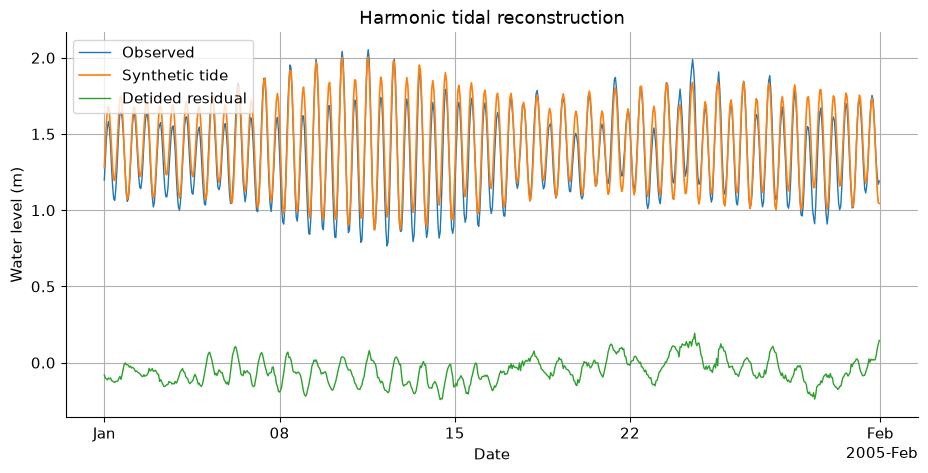

In [6]:
# PLOT DETIDED DATA
# Plotting parameters
PLOT_START = "2005-01-01"
PLOT_END = "2005-01-31"

# Produce the plot
plot_data = section2.loc[PLOT_START:PLOT_END]
fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["observed"], label="Observed", lw=1)
ax.plot(plot_data.index, plot_data["synthetic_tide"], label="Synthetic tide", lw=1.2)
ax.plot(plot_data.index, plot_data["detided"], label="Detided residual", lw=1)
ax.set(xlabel="Date", ylabel="Water level (m)", title="Harmonic tidal reconstruction")
format_date_axis(ax)
ax.legend()
plt.show()

# Section 3 — Long-term relative sea-level trend

Assuming we have sufficiently removed all the tidal variability from the sea level record, what mechanisms are there behind the variability that remains? Over the time period of the complete dataset, the observed trend will reflect the local trend in sea level resulting from changes in volume, changes in mass, and glacial isostatic adjustment. Therefore, we can use the detided sea level record from the tide gauge to determine the total trend in local sea level rise. 

In section 2, we ran the harmonic analysis over only a single year. This sped things up, allowing us to test different combinations of tidal constituents quickly. This time, we are going to instead run a harmonic analysis over the entire dataset. To stop this calculation from taking forever, we are (i) not going to calculate confidence intervals for the individual constituent fits this time and (ii) will use a fixed list of 8 tidal constituents (all constituents with a larger amplitude than 2 cm from the NOAA record).

As in section 2, the code below first performs a harmonic analysis (except on the entire dataset rather than just one year) and produces a detided sea level dataset. We could fit a linear trend to the full hourly detided sea level dataset, but can you think of why this may cause problems for linear regression, in particular estimates of statistical significance? Instead, we are going to calculate annual averages (at first), discarding years with insufficient data, and calculate the linear trend based on annual averages rather than the full hourly data. We will also calculate a 95% confidence interval (using the student's t-test). By default, the start and end dates for the linear trend are the start and end of the full dataset, but you can change these to calculate linear trends over subsets of the time series.

What trend do you get, and how does it compare with the value provided by NOAA [here](https://tidesandcurrents.noaa.gov/trends-and-extremes/main-product.html?mapTab=station&tab=trends&station-id=2695540&plot=relative-sea-level-change-ntde)? Alter the period of time over which the trend is calculated. Is the trend constant? What are the implications of this? Try changing whether the code calculates the linear trend based on annual, monthly, or daily means, or the original (hourly) data - how does this change the results, and why? Given the information on the NOAA website, how closely can you recreate the 'official' sea level trend?

In [7]:
# This block of code performs the harmonic analysis on the full time-series. This may take a short while to run,
# but you should only need to run it once!
FULL_RECORD_CONSTITUENTS = ["M2", "S2", "N2", "K1", "O1", "SA", "P1", "K2"] 

valid_tg = tg.dropna()
print(f"Fitting {len(FULL_RECORD_CONSTITUENTS)} constituents to {len(valid_tg):,} valid observations...")

coef_full = solve(
    valid_tg.index.to_numpy(),
    valid_tg.to_numpy(),
    lat=TIDE_GAUGE_LAT,
    constit=FULL_RECORD_CONSTITUENTS,
    trend=False,
    nodal=True,
    method="ols",
    conf_int="none",     # faster for the long fit; Section 2 demonstrates constituent CIs
    verbose=False,
)

full_tide = reconstruct(
    tg.index.to_numpy(),
    coef_full,
    constit=FULL_RECORD_CONSTITUENTS,
    verbose=False,
).h

# UTide's reconstruction includes the fitted mean. Remove only the tidal anomaly
# so that the tide-gauge datum/mean level remains in the detided record.
tidal_anomaly = full_tide - np.nanmean(full_tide)
detided_tg = pd.Series(tg.to_numpy() - tidal_anomaly, index=tg.index, name="detided_m")

# Plot the tidal constituents table
constituent_table = pd.DataFrame({
    "Constituent": coef_full.name,
    "Amplitude (m)": [str(round(amp, 3)) for amp in coef_full.A],
    "Greenwhich phase (°)": [str(round(amp, 1)) for amp in coef_full.g],
})
constituent_table
constituent_table.style.set_caption('Fitted tidal constituents')

Fitting 8 constituents to 525,701 valid observations...


,Constituent,Amplitude (m),Greenwhich phase (°)
0,M2,0.361,358.8
1,N2,0.082,338.5
2,S2,0.081,25.0
3,SA,0.071,266.8
4,K1,0.066,186.5
5,O1,0.053,192.2
6,K2,0.022,23.9
7,P1,0.02,188.5


In [35]:
# Calculate a linear trend using annual/monthly/daily/hourly means
AVERAGING_WINDOW = 'MS' # Options: 'YS' = Annual, 'MS' = Monthly, 'D' = Daily, 'h' = Hourly
TREND_START = None   # e.g. "1950-01-01"; None uses the first usable year
TREND_END = None     # e.g. "2012-12-31"; None uses the last usable year
CONFIDENCE = 0.95    # For sea-level rise linear fit
MIN_ANNUAL_COVERAGE = 0.50

coarsened_tg, coverage = interval_mean(detided_tg, freq=AVERAGING_WINDOW, min_coverage=MIN_ANNUAL_COVERAGE)
tg_trend = fit_linear_trend(
    coarsened_tg,
    start=TREND_START,
    end=TREND_END,
    confidence=CONFIDENCE,
)

print(
    f"Relative sea-level trend = {tg_trend['slope_mm_per_year']:.2f} ± "
    f"{tg_trend['slope_ci_half_mm_per_year']:.2f} mm/yr "
    f"({CONFIDENCE:.0%} OLS slope CI; n={tg_trend['n_years']} annual means)"
)
print(f"R² = {tg_trend['r_squared']:.3f}")

Relative sea-level trend = 2.03 ± 0.27 mm/yr (95% OLS slope CI; n=721 annual means)
R² = 0.234


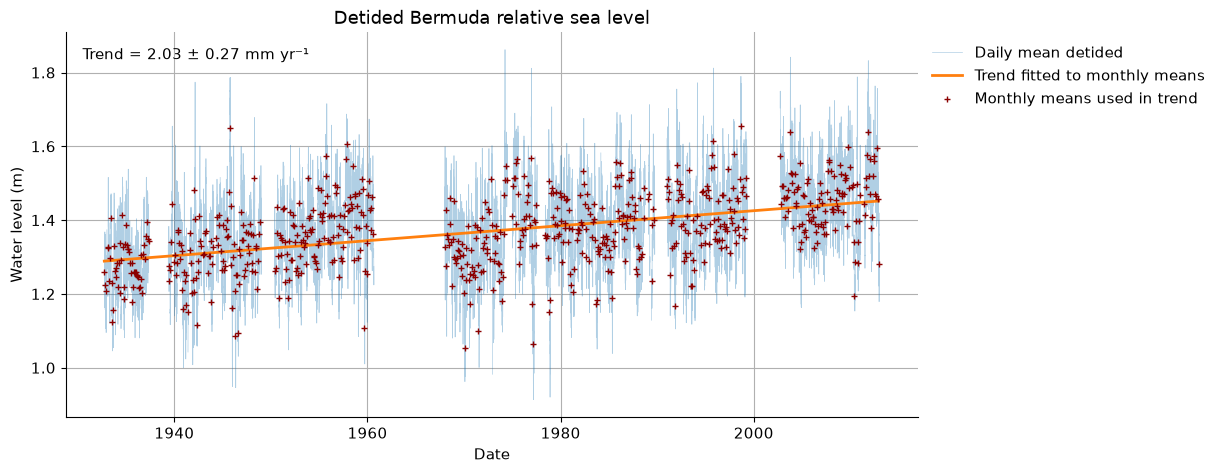

In [36]:
# CREATE A FIGURE
fig, ax = plt.subplots()
daily_detided = detided_tg.resample("D").mean() # Plot detided curve (as daily means)
ax.plot(daily_detided.index, daily_detided, lw=0.5, alpha=0.35, label="Daily mean detided")
label = {'YS': 'annual', 'MS': 'monthly', 'D': 'daily', 'h': 'hourly'}[AVERAGING_WINDOW]
ax.plot(tg_trend["fitted"].index, tg_trend["fitted"], lw=2,
        label='Trend fitted to ' + label + ' means') # Plot trend
ax.scatter(tg_trend["data"].index, tg_trend["data"], s=20, c='darkred', zorder=4,
           marker='+', lw=1, label=(label.capitalize() + ' means used in trend')) 
ax.set(xlabel="Date", ylabel="Water level (m)", title="Detided Bermuda relative sea level")
format_date_axis(ax)
ax.legend(ncol=1, frameon=False, loc='upper left', bbox_to_anchor=(1,1))
ax.text(
    0.02, 0.96,
    f"Trend = {tg_trend['slope_mm_per_year']:.2f} ± {tg_trend['slope_ci_half_mm_per_year']:.2f} mm yr⁻¹",
    transform=ax.transAxes, va="top",
)
plt.show()

# Section 4 — Steric sea-level contribution from BATS hydrography

The final section of the practical is to try and quantify what proportion of the total sea level trend can be accounted for by steric sea level rise. Steric sea level rise arises from changes in the temperature and salinity of the water column that modify the density (and therefore volume, and therefore height). Using the temperature and salinity data collected at the BATS site between 1955 and 2011, the steric height between the surface and 2000 m is calculated as the vertically integrated departure of density $\rho$ at salinity $S$, temperature $T$, and pressure $P$ from a standard reference value, that is:

$$\rho_{ref} = \rho\left(T_{ref}, S_{ref}, P_{ref}\right)$$
$$\eta_s = \int \frac{\rho_{ref}-\rho}{\rho_{ref}}\,dz.$$

where we use $T_{ref}=0\ ^\circ \mathrm{C}$, $S_{ref}=35$, and $P=2000\ \mathrm{dbar}$. Similar to the analysis of the tide gauge data, we can then fit a linear trend to the aggregated annual data (this time we will not try out monthly or daily aggregates due to the BATS sampling interval) and calculate confidence intervals to investigate what proportion of the observed sea level rise can be accounted for by steric effects.

Across the entire time period, what proportion of the total sea level rise trend is accounted for by steric effects? Does this proportion change if you calculate the trend over different periods? What processes are responsible for the remaining proportion of the total sea level trend?

In [62]:
REFERENCE_SP = 35.0
REFERENCE_T_C = 0.0
MAX_PRESSURE_DBAR = 2000.0
MIN_CASTS_PER_YEAR = 3
STERIC_TREND_START = None # Remember, the format is 'YYYY-MM-DD' if you want to change it
STERIC_TREND_END = None

# Load the BATS data
bats = load_bats_ts(BATS_TS_FILE)
print(
    f"BATS profiles: {bats['time'].min()} to {bats['time'].max()} "
    f"({len(bats['time'])} processed casts)"
)

# Function to calculate the steric height based on BATS data for each cast
def steric_height_profile(sp, temp, pressure, lat=BATS_LAT, lon=BATS_LON):
    """Calculate steric height (m) relative to SP=35, t=0 °C down to 2000 dbar."""
    good = np.isfinite(sp) & np.isfinite(temp) & np.isfinite(pressure) # Require that T, S, P are all present
    sp = np.asarray(sp[good], dtype=float)
    temp = np.asarray(temp[good], dtype=float)
    pressure = np.asarray(pressure[good], dtype=float)

    order = np.argsort(pressure) # Ensure profiles are correctly sorted by depth (pressure)
    pressure, sp, temp = pressure[order], sp[order], temp[order]

    # Remove duplicate pressure levels before interpolation.
    pressure, unique_index = np.unique(pressure, return_index=True)
    sp, temp = sp[unique_index], temp[unique_index]

    # Require near-full column coverage. A few archived casts end slightly above
    # 2000 dbar, so allow modest endpoint interpolation/extrapolation (<=100 dbar).
    if pressure.size < 3 or pressure.min() > 20 or pressure.max() < 1900:
        return np.nan

    # Standardise every profile to exactly 0-2000 dbar. np.interp uses the
    # nearest endpoint value for the small extrapolation to 0 or 2000 dbar.
    interior = pressure[(pressure > 0) & (pressure < MAX_PRESSURE_DBAR)]
    p_grid = np.unique(np.concatenate(([0.0], interior, [MAX_PRESSURE_DBAR])))
    sp_grid = np.interp(p_grid, pressure, sp)
    t_grid = np.interp(p_grid, pressure, temp)

    # Layer-midpoint properties.
    p_mid = 0.5 * (p_grid[:-1] + p_grid[1:])
    sp_mid = 0.5 * (sp_grid[:-1] + sp_grid[1:])
    t_mid = 0.5 * (t_grid[:-1] + t_grid[1:])

    # Convert observational variables to TEOS-10 variables.
    sa = gsw.SA_from_SP(sp_mid, p_mid, lon, lat)
    ct = gsw.CT_from_t(sa, t_mid, p_mid)
    rho = gsw.rho(sa, ct, p_mid)

    # Apply the same conversion to the reference water mass.
    sp_ref = np.full_like(p_mid, REFERENCE_SP)
    t_ref = np.full_like(p_mid, REFERENCE_T_C)
    sa_ref = gsw.SA_from_SP(sp_ref, p_mid, lon, lat)
    ct_ref = gsw.CT_from_t(sa_ref, t_ref, p_mid)
    rho_ref = gsw.rho(sa_ref, ct_ref, p_mid)

    # gsw.z_from_p returns height relative to sea level (negative below sea level).
    z = gsw.z_from_p(p_grid, lat)
    dz = np.abs(np.diff(z))

    return np.sum((rho_ref - rho) / rho_ref * dz)

# Calculate steric height for each cast
steric_values = np.array([
    steric_height_profile(
        bats["salinity"][:, i],
        bats["temperature"][:, i],
        bats["pressure"][:, i],
    )
    for i in range(len(bats["time"]))
])

steric = pd.Series(steric_values, index=bats["time"], name="steric_height_m").sort_index()

# Get annual aggregates (discarding years with fewer than MIN_CASTS_PER_YEAR casts)
steric_annual = steric.resample("YS").mean()
steric_cast_count = steric.resample("YS").count()
steric_annual = steric_annual.where(steric_cast_count >= MIN_CASTS_PER_YEAR)

print(f"Valid steric-height estimates: {steric.notna().sum()} / {len(steric)} profiles")

BATS profiles: 1955-03-10 16:17:02 to 2011-12-11 06:57:36 (731 processed casts)
Valid steric-height estimates: 725 / 731 profiles


We are now going to calculate the linear trend in steric height and compare this to the linear trend in (detided) total sea level.

In [63]:
# Recalculate detided sea level as annual means for direct comparison to annual steric height estimates
annual_tg, coverage = interval_mean(detided_tg, freq='YS', min_coverage=MIN_ANNUAL_COVERAGE)

# Align both time-series (detided sea level and steric height)
comparison = pd.concat(
    [annual_tg.rename("relative_sea_level_m"), steric_annual.rename("steric_height_m")],
    axis=1,
).dropna()

# Restrict comparison to chosen interval
if STERIC_TREND_START is not None:
    comparison = comparison.loc[pd.Timestamp(STERIC_TREND_START + 'T12'):]
if STERIC_TREND_END is not None:
    comparison = comparison.loc[:pd.Timestamp(STERIC_TREND_END + 'T12')]

if len(comparison) < 3:
    raise ValueError("Too few common annual values to compare tide-gauge and steric trends.")

# Calculate linear trends over chosen interval.
# Important note: the linear trend calculated here may not be identical to the trend calculated in
# section 3, as we are now only using data from years where there is sufficient data from *both* BATS
# and the tide gauge.
common_tg_trend = fit_linear_trend(
    comparison["relative_sea_level_m"], confidence=CONFIDENCE
)
common_steric_trend = fit_linear_trend(
    comparison["steric_height_m"], confidence=CONFIDENCE
)

# Compare linear trends and print results
steric_fraction_percent = (
    100 * common_steric_trend["slope_mm_per_year"] / common_tg_trend["slope_mm_per_year"]
)

print(
    f"Common comparison years: {comparison.index.min().year}–{comparison.index.max().year} "
    f"({len(comparison)} years)"
)
print(
    f"Tide-gauge trend: {common_tg_trend['slope_mm_per_year']:.2f} ± "
    f"{common_tg_trend['slope_ci_half_mm_per_year']:.2f} mm/yr"
)
print(
    f"Steric trend:     {common_steric_trend['slope_mm_per_year']:.2f} ± "
    f"{common_steric_trend['slope_ci_half_mm_per_year']:.2f} mm/yr"
)
print(f"Steric trend / relative sea-level trend = {steric_fraction_percent:.1f}%")

Common comparison years: 1955–2011 (36 years)
Tide-gauge trend: 1.61 ± 1.07 mm/yr
Steric trend:     0.86 ± 1.14 mm/yr
Steric trend / relative sea-level trend = 53.7%


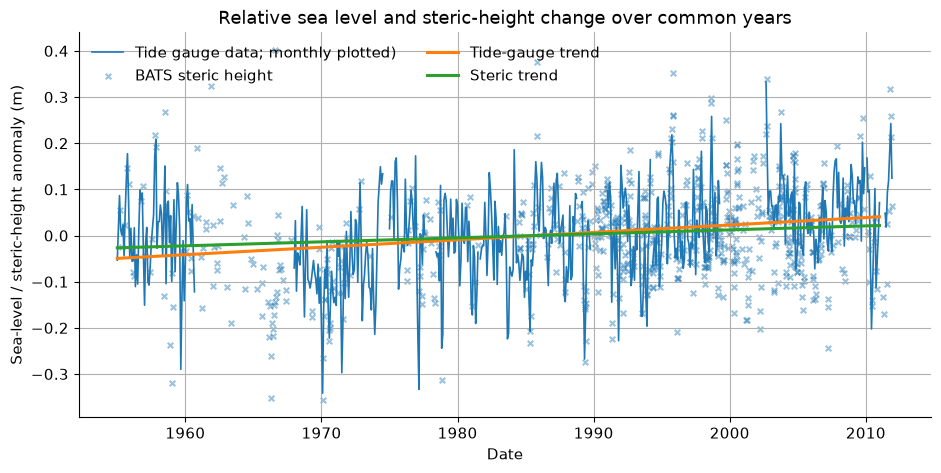

In [64]:
# Plot data
# For clarity, we are going to plot monthly means in (detided) tide gauge data against BATS steric height, but 
# remember that the linear trends are calculated using the annual aggregates.
start_common = comparison.index.min()
end_common = comparison.index.max() + pd.offsets.YearEnd(0)

tg_monthly_plot = detided_tg.resample("MS").mean().loc[start_common:end_common]
steric_plot = steric.loc[start_common:end_common]

tg_center = tg_monthly_plot.mean()
steric_center = steric_plot.mean()

fig, ax = plt.subplots()
ax.plot(
    tg_monthly_plot.index,
    tg_monthly_plot - tg_center,
    lw=1.2,
    label=f"Tide gauge data; monthly plotted)",
)
ax.scatter(
    steric_plot.index,
    steric_plot - steric_center,
    s=16,
    alpha=0.45,
    marker="x",
    label="BATS steric height",
)

# Trend lines, mean-centred independently.
tg_fit_plot = common_tg_trend["fitted"] - common_tg_trend["fitted"].mean()
sh_fit_plot = common_steric_trend["fitted"] - common_steric_trend["fitted"].mean()
ax.plot(tg_fit_plot.index, tg_fit_plot, lw=2.2, label="Tide-gauge trend")
ax.plot(sh_fit_plot.index, sh_fit_plot, lw=2.2, label="Steric trend")

ax.set(
    xlabel="Date",
    ylabel="Sea-level / steric-height anomaly (m)",
    title="Relative sea level and steric-height change over common years",
)
format_date_axis(ax)
ax.legend(ncol=2, frameon=False)
plt.show()